In [25]:
#system
import psutil
import time
import csv
import os
import sqlite3
import shutil
from datetime import datetime

#data wrangling
import pandas as pd
from urllib.parse import urlsplit
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, silhouette_score

#deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Ram Data Collection

In [2]:
def log_ram(interval=5, output_file='data/raw/ram_log_last5days.csv'):
    # Write header if file doesn't exist
    file_exists = os.path.isfile(output_file)

    print(f"Starting RAM logger. Interval: {interval}s. Logging to {output_file}...")
    print("Press Ctrl+C to stop.")

    try:
        with open(output_file, 'a', newline='') as f:
            writer = csv.writer(f)
            if not file_exists:
                writer.writerow(['timestamp', 'total_mb', 'used_mb', 'available_mb', 'usage_percent'])

            while True:
                mem = psutil.virtual_memory()
                timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

                # Convert bytes to MB
                total = round(mem.total / (1024**2), 2)
                used = round(mem.used / (1024**2), 2)
                available = round(mem.available / (1024**2), 2)
                percent = mem.percent

                writer.writerow([timestamp, total, used, available, percent])
                f.flush() # Ensure data is written to disk

                time.sleep(interval)
    except KeyboardInterrupt:
        print("\nLogging stopped by user.")

if __name__ == "__main__":
    log_ram()

Starting RAM logger. Interval: 5s. Logging to data/raw/ram_log_last5days.csv...
Press Ctrl+C to stop.


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/ram_log_last5days.csv'

# Chrome Data Collection

In [ ]:
def extract_chrome_history():

    history_path = os.path.expanduser("~/.config/google-chrome/Default/History")

    if not os.path.exists(history_path):
        print("Chrome History file not found at the standard location.")
        print("Please manually update the 'history_path' variable in the script.")
        return

    # Create a temporary copy to avoid "Database locked" error if Chrome is open
    temp_history = "temp_chrome_history"
    shutil.copy2(history_path, temp_history)

    try:
        conn = sqlite3.connect(temp_history)
        query = """
        SELECT
            datetime(last_visit_time/1000000-11644473600, 'unixepoch', 'localtime') as timestamp,
            url,
            title
        FROM urls
        ORDER BY last_visit_time DESC
        """
        df = pd.read_csv(conn.execute(query))

        df = pd.read_sql_query(query, conn)

        # Save to CSV
        output_file = '/home/abishek/projects/guvi-final/data/raw/browsing_history_last5days.csv'
        df.to_csv(output_file, index=False)
        print(f"Successfully extracted {len(df)} records to {output_file}")

    except Exception as e:
        print(f"Error: {e}")
    finally:
        conn.close()
        if os.path.exists(temp_history):
            os.remove(temp_history)

if __name__ == "__main__":
    extract_chrome_history()

Chrome History file not found at the standard location.
Please manually update the 'history_path' variable in the script.


In [3]:
chrome_data = pd.read_csv('/home/abishek/projects/guvi-final/data/raw/browsing_history_last5days.csv')
ram_data = pd.read_csv('/home/abishek/projects/guvi-final/data/raw/ram_log_last5days.csv')

In [4]:
chrome_data.shape, ram_data.shape

((24321, 7), (103680, 5))

# Data Preprocessing


In [5]:
display(chrome_data.head())
display(ram_data.head())

,timestamp,url,title,domain,browser,hour,date
0,2026-08-01 09:24:00,https://docs.google.com/document/d/1T-025gZuZ4...,DS105_Final_Project.docx - Google Docs,docs.google.com,chrome,09:24,2026-08-01
1,2026-08-01 09:24:14,https://docs.google.com/document/d/1T-025gZuZ4...,DS105_Final_Project.docx - Google Docs,docs.google.com,chrome,09:24,2026-08-01
2,2026-08-01 09:24:29,https://docs.google.com/document/d/1T-025gZuZ4...,DS105_Final_Project.docx - Google Docs,docs.google.com,chrome,09:24,2026-08-01
3,2026-08-01 09:24:44,https://docs.google.com/document/d/1T-025gZuZ4...,DS105_Final_Project.docx - Google Docs,docs.google.com,chrome,09:24,2026-08-01
4,2026-08-01 09:23:00,https://drive.google.com/drive/u/0/home,Home - Google Drive,drive.google.com,chrome,09:23,2026-08-01


,timestamp,total_mb,used_mb,available_mb,usage_percent
0,2026-05-03 00:00:00,8192,3522.0,4670.0,42.99
1,2026-05-03 00:00:05,8192,3771.6,4420.4,46.04
2,2026-05-03 00:00:10,8192,3829.4,4362.6,46.75
3,2026-05-03 00:00:15,8192,3297.3,4894.7,40.25
4,2026-05-03 00:00:20,8192,3509.0,4683.0,42.83


In [6]:
# 1. Clean URL and extract domain, remove sensitive URL parts (query strings)
def clean_and_extract_url_parts(url):
    try:
        parsed_url = urlsplit(url)
        cleaned_url = urlsplit(url)._replace(query='', fragment='').geturl() 
        domain = parsed_url.netloc.replace('www.', '')
        return cleaned_url, domain
    except Exception:
        # If parsing fails, return original URL and NaN for domain
        return url, np.nan

In [7]:
# Apply the cleaning and domain extraction. pd.Series is used to assign multiple outputs to new columns.
chrome_data[['url', 'domain']] = chrome_data['url'].apply(lambda x: pd.Series(clean_and_extract_url_parts(x)))

In [8]:
chrome_data.head()

,timestamp,url,title,domain,browser,hour,date
0,2026-08-01 09:24:00,https://docs.google.com/document/d/1T-025gZuZ4...,DS105_Final_Project.docx - Google Docs,docs.google.com,chrome,09:24,2026-08-01
1,2026-08-01 09:24:14,https://docs.google.com/document/d/1T-025gZuZ4...,DS105_Final_Project.docx - Google Docs,docs.google.com,chrome,09:24,2026-08-01
2,2026-08-01 09:24:29,https://docs.google.com/document/d/1T-025gZuZ4...,DS105_Final_Project.docx - Google Docs,docs.google.com,chrome,09:24,2026-08-01
3,2026-08-01 09:24:44,https://docs.google.com/document/d/1T-025gZuZ4...,DS105_Final_Project.docx - Google Docs,docs.google.com,chrome,09:24,2026-08-01
4,2026-08-01 09:23:00,https://drive.google.com/drive/u/0/home,Home - Google Drive,drive.google.com,chrome,09:23,2026-08-01


In [9]:
domain_to_category_mapping = {
    # Ads/Suspicious Redirects
    '17.infracells.com': 'Ads/Suspicious Redirects',
    '5350.xg4ken.com': 'Ads/Suspicious Redirects',
    'ad.doubleclick.net': 'Ads/Suspicious Redirects',
    'adclick.g.doubleclick.net': 'Ads/Suspicious Redirects',
    'adv.clickadu.net': 'Ads/Suspicious Redirects',
    'afterlandos.xyz': 'Ads/Suspicious Redirects',
    'ardoprenuls.xyz': 'Ads/Suspicious Redirects',
    'b7510.com': 'Ads/Suspicious Redirects',
    'beesratyou.com': 'Ads/Suspicious Redirects',
    'click.flamyadsserv.com': 'Ads/Suspicious Redirects',
    'click.liftoff.io': 'Ads/Suspicious Redirects',
    'click4.liftoff.io': 'Ads/Suspicious Redirects',
    'corevibe-network.com': 'Ads/Suspicious Redirects',
    'dr-blanca-mhfscak.work': 'Ads/Suspicious Redirects',
    'dz.rheumicprofit.shop': 'Ads/Suspicious Redirects',
    'ew.colimaunmoral.cyou': 'Ads/Suspicious Redirects',
    'googleadservices.com': 'Ads/Suspicious Redirects',
    'gotopage.top': 'Ads/Suspicious Redirects',
    'hexoic.ribsiuds.qpon': 'Ads/Suspicious Redirects',
    'hl.sambaraethoses.cyou': 'Ads/Suspicious Redirects',
    'ilyvo.com': 'Ads/Suspicious Redirects',
    'infracells.com': 'Ads/Suspicious Redirects',
    'kekwvl.pulseofpassion.com': 'Ads/Suspicious Redirects',
    'landht.com': 'Ads/Suspicious Redirects',
    'luugy.com': 'Ads/Suspicious Redirects',
    'masonerthoria.shop': 'Ads/Suspicious Redirects',
    'niaf.pics': 'Ads/Suspicious Redirects',
    'of.erniefilaree.shop': 'Ads/Suspicious Redirects',
    'p1.me-page.org': 'Ads/Suspicious Redirects',
    'portslocked.com': 'Ads/Suspicious Redirects',
    'reserveinreverunivers.site': 'Ads/Suspicious Redirects',
    'robomiracle.com': 'Ads/Suspicious Redirects',
    'royaldepotscrewdriver.com': 'Ads/Suspicious Redirects',
    's.viieuvkf.com': 'Ads/Suspicious Redirects',
    'surfgold.net': 'Ads/Suspicious Redirects',
    'tcl.ltd': 'Ads/Suspicious Redirects',
    'theskybrisk.com': 'Ads/Suspicious Redirects',
    'track.laros.world': 'Ads/Suspicious Redirects',
    'trendnotify.my': 'Ads/Suspicious Redirects',
    'tsyndicate.com': 'Ads/Suspicious Redirects',
    'u.viifwjox.com': 'Ads/Suspicious Redirects',
    'ultraviax.org': 'Ads/Suspicious Redirects',
    'vaultorial.com': 'Ads/Suspicious Redirects',
    'vp.redrooturgence.cfd': 'Ads/Suspicious Redirects',
    'weneverbeenfree.com': 'Ads/Suspicious Redirects',
    'yh.twierglans.cyou': 'Ads/Suspicious Redirects',
    'zurl.site': 'Ads/Suspicious Redirects',
    # Adult Content
    'xhaccess.com': 'Adult Content',
    'xhamster45.desi': 'Adult Content',
    # Automotive
    'atherenergy.com': 'Automotive',
    'bikewale.com': 'Automotive',
    'book.olaelectric.com': 'Automotive',
    'brabus.com': 'Automotive',
    'bustimes.in': 'Automotive',
    'landrover.in': 'Automotive',
    'mansory.com': 'Automotive',
    'olaelectric.com': 'Automotive',
    'tvsmotor.com': 'Automotive',
    # Development/Local
    '10.136.102.219:5000': 'Development/Local',
    '10.172.67.41:5173': 'Development/Local',
    '10.205.22.10:5000': 'Development/Local',
    '127.0.0.1:34997': 'Development/Local',
    '127.0.0.1:35587': 'Development/Local',
    '127.0.0.1:37881': 'Development/Local',
    '127.0.0.1:38053': 'Development/Local',
    '127.0.0.1:38975': 'Development/Local',
    '127.0.0.1:40099': 'Development/Local',
    '127.0.0.1:41165': 'Development/Local',
    '127.0.0.1:41415': 'Development/Local',
    '127.0.0.1:41433': 'Development/Local',
    '127.0.0.1:42627': 'Development/Local',
    '127.0.0.1:42923': 'Development/Local',
    '127.0.0.1:43043': 'Development/Local',
    '127.0.0.1:43569': 'Development/Local',
    '127.0.0.1:43649': 'Development/Local',
    '127.0.0.1:4381': 'Development/Local',
    '127.0.0.1:44915': 'Development/Local',
    '127.0.0.1:45475': 'Development/Local',
    '127.0.0.1:46069': 'Development/Local',
    '127.0.0.1:46211': 'Development/Local',
    'localhost:1455': 'Development/Local',
    'localhost:3000': 'Development/Local',
    'localhost:5000': 'Development/Local',
    'localhost:8501': 'Development/Local',
    'localhost:8502': 'Development/Local',
    'localhost:8503': 'Development/Local',
    # Entertainment/Media
    'accounts.spotify.com': 'Entertainment/Media',
    'alphacoders.com': 'Entertainment/Media',
    'gaana.com': 'Entertainment/Media',
    'hotstar.com': 'Entertainment/Media',
    'imdb.com': 'Entertainment/Media',
    'in.bookmyshow.com': 'Entertainment/Media',
    'iw4x.io': 'Entertainment/Media',
    'moviebuff.com': 'Entertainment/Media',
    'open.spotify.com': 'Entertainment/Media',
    'openart.ai': 'Entertainment/Media',
    'play.google.com': 'Entertainment/Media',
    'primevideo.com': 'Entertainment/Media',
    'spotify.com': 'Entertainment/Media',
    'store.steampowered.com': 'Entertainment/Media',
    'tamildailycalendar.com': 'Entertainment/Media',
    'terminator.fandom.com': 'Entertainment/Media',
    'tokenized.play.google.com': 'Entertainment/Media',
    'wallpaperaccess.com': 'Entertainment/Media',
    'wallpapercave.com': 'Entertainment/Media',
    # Finance
    'americanexpress.com': 'Finance',
    'bajajfinserv.in': 'Finance',
    'bluestock.in': 'Finance',
    'cibil.com': 'Finance',
    'evt.paytm.com': 'Finance',
    'hdbfs.com': 'Finance',
    'hdfc.bank.in': 'Finance',
    'instaloan.tatacapital.com': 'Finance',
    'merchant.now.hdfc.bank.in': 'Finance',
    'pay.billdesk.com': 'Finance',
    'paymentsredirectionservice.cp.microsoft.com': 'Finance',
    'securehdfc-acs2ui-b1-indblr-blrrel.hdfc.bank.in': 'Finance',
    'tatacapital.com': 'Finance',
    'tu1.cibil.com': 'Finance',
    'udyamregistration.gov.in': 'Finance',
    'zaubacorp.com': 'Finance',
    # Government
    'accounts.digitallocker.gov.in': 'Government',
    'api.digitallocker.gov.in': 'Government',
    'capiaa.ca.gov': 'Government',
    'consent.digilocker.gov.in': 'Government',
    'drdo.gov.in': 'Government',
    'parivahan.gov.in': 'Government',
    'results.eci.gov.in': 'Government',
    'staging.parivahan.nic.in': 'Government',
    'tnebltd.gov.in': 'Government',
    'tnuwwb.tn.gov.in': 'Government',
    'vahan.parivahan.gov.in': 'Government',
    # Job Search/Career
    'amazon.jobs': 'Job Search/Career',
    'app.deel.com': 'Job Search/Career',
    'blackrock.com': 'Job Search/Career',
    'buildings.honeywell.com': 'Job Search/Career',
    'careers.algoleap.com': 'Job Search/Career',
    'careers.blackrock.com': 'Job Search/Career',
    'careers.capgemini.com': 'Job Search/Career',
    'careers.honeywell.com': 'Job Search/Career',
    'careers.ibm.com': 'Job Search/Career',
    'careers.quest-global.com': 'Job Search/Career',
    'careerzenith.ai': 'Job Search/Career',
    'enhancv.com': 'Job Search/Career',
    'f6s.com': 'Job Search/Career',
    'foundit.in': 'Job Search/Career',
    'go1.trakit30.com': 'Job Search/Career',
    'grnh.se': 'Job Search/Career',
    'honeywell.com': 'Job Search/Career',
    'hypersonix.applytojob.com': 'Job Search/Career',
    'in.indeed.com': 'Job Search/Career',
    'jobs.deel.com': 'Job Search/Career',
    'jobs.nvidia.com': 'Job Search/Career',
    'lmwanubhav.darwinbox.in': 'Job Search/Career',
    'naukri.com': 'Job Search/Career',
    'resume.io': 'Job Search/Career',
    'rootsindia.zohorecruit.in': 'Job Search/Career',
    'round1.grapevine.in': 'Job Search/Career',
    'search.jobs.barclays': 'Job Search/Career',
    'secure.indeed.com': 'Job Search/Career',
    'skylinkfibernet.zohorecruit.in': 'Job Search/Career',
    'unjob.ai': 'Job Search/Career',
    # Learning/Education
    'ageron.github.io': 'Learning/Education',
    'analyticsdata24.wordpress.com': 'Learning/Education',
    'archive.ics.uci.edu': 'Learning/Education',
    'arxiv.org': 'Learning/Education',
    'colab.research.google.com': 'Learning/Education',
    'coursera.org': 'Learning/Education',
    'customer-academy.databricks.com': 'Learning/Education',
    'dataannotation.tech': 'Learning/Education',
    'dev.to': 'Learning/Education',
    'devblogs.microsoft.com': 'Learning/Education',
    'developer.nvidia.com': 'Learning/Education',
    'developers.google.com': 'Learning/Education',
    'developers.redhat.com': 'Learning/Education',
    'digitalskills.iitmpravartak.org.in': 'Learning/Education',
    'digitalskills.pravartak.org.in': 'Learning/Education',
    'docs.astral.sh': 'Learning/Education',
    'docs.docker.com': 'Learning/Education',
    'docs.github.com': 'Learning/Education',
    'docs.pola.rs': 'Learning/Education',
    'docs.python.org': 'Learning/Education',
    'docs.pytorch.org': 'Learning/Education',
    'docs.rapids.ai': 'Learning/Education',
    'docs.ros.org': 'Learning/Education',
    'docs.scipy.org': 'Learning/Education',
    'docs.ultralytics.com': 'Learning/Education',
    'fastapi.tiangolo.com': 'Learning/Education',
    'forum.obsidian.md': 'Learning/Education',
    'freecodecamp.org': 'Learning/Education',
    'gazebosim.org': 'Learning/Education',
    'geeksforgeeks.org': 'Learning/Education',
    'gist.github.com': 'Learning/Education',
    'git-scm.com': 'Learning/Education',
    'github.blog': 'Learning/Education',
    'github.com': 'Learning/Education',
    'guvi.in': 'Learning/Education',
    'howtogeek.com': 'Learning/Education',
    'huggingface.co': 'Learning/Education',
    'imarticus.org': 'Learning/Education',
    'internshala.com': 'Learning/Education',
    'itsfoss.com': 'Learning/Education',
    'kaggle.com': 'Learning/Education',
    'karthiktechdairy.substack.com': 'Learning/Education',
    'learn-xpro.mit.edu': 'Learning/Education',
    'learn.microsoft.com': 'Learning/Education',
    'learn.nvidia.com': 'Learning/Education',
    'learnopencv.com': 'Learning/Education',
    'linuxano.com': 'Learning/Education',
    'linuxblog.io': 'Learning/Education',
    'medicalnewstoday.com': 'Learning/Education',
    'medium.com': 'Learning/Education',
    'microsoftlearning.github.io': 'Learning/Education',
    'nasa.gov': 'Learning/Education',
    'nnfs.io': 'Learning/Education',
    'nvidia.com': 'Learning/Education',
    'offsec.com': 'Learning/Education',
    'openlearning.mit.edu': 'Learning/Education',
    'oreilly.com': 'Learning/Education',
    'pandas.pydata.org': 'Learning/Education',
    'pmc.ncbi.nlm.nih.gov': 'Learning/Education',
    'pola.rs': 'Learning/Education',
    'pubs.acs.org': 'Learning/Education',
    'pytorch.org': 'Learning/Education',
    'raw.githubusercontent.com': 'Learning/Education',
    'research.google.com': 'Learning/Education',
    'research.nvidia.com': 'Learning/Education',
    'researchgate.net': 'Learning/Education',
    'ros.org': 'Learning/Education',
    'science.nasa.gov': 'Learning/Education',
    'scikit-learn.org': 'Learning/Education',
    'sebastianraschka.com': 'Learning/Education',
    'soclibrary.futa.edu.ng': 'Learning/Education',
    'speak.google.com': 'Learning/Education',
    'stackoverflow.com': 'Learning/Education',
    'substack.com': 'Learning/Education',
    'tensorflow.org': 'Learning/Education',
    'thoughtsclub.substack.com': 'Learning/Education',
    'trainings.internshala.com': 'Learning/Education',
    'unifiedmentor.com': 'Learning/Education',
    'upes.ac.in': 'Learning/Education',
    'w3schools.com': 'Learning/Education',
    'wiki.ros.org': 'Learning/Education',
    'yolov8.com': 'Learning/Education',
    'zenclass.in': 'Learning/Education',
    # News
    '9to5google.com': 'News',
    'cnbctv18.com': 'News',
    'edition.cnn.com': 'News',
    'hindustantimes.com': 'News',
    'jagranjosh.com': 'News',
    'linuxiac.com': 'News',
    'news.google.com': 'News',
    'phoronix.com': 'News',
    'sabrangindia.in': 'News',
    'telegraphindia.com': 'News',
    'thehindu.com': 'News',
    'theprint.in': 'News',
    'timesofindia.indiatimes.com': 'News',
    'xda-developers.com': 'News',
    'zdnet.com': 'News',
    # Other
    '1kx.in': 'Other',
    '99acres.com': 'Other',
    'acaciaworld.com': 'Other',
    'accounts.eternal.com': 'Other',
    'ai.google.dev': 'Other',
    'ak-motofix-invoice.vercel.app': 'Other',
    'alextade.me': 'Other',
    'bqpsim.com': 'Other',
    'cdn.bollywoodmenswear.com': 'Other',
    'dataatuci.com': 'Other',
    'dc.1kx.in': 'Other',
    'dfindia.com': 'Other',
    'docs.andronix.app': 'Other',
    'dummyjson.com': 'Other',
    'effectivecpmnetwork.com': 'Other',
    'emergertech.com': 'Other',
    'enterprise.dji.com': 'Other',
    'enthum-foundation.raiselysite.com': 'Other',
    'forms.eternal.com': 'Other',
    'interlinecustomroofingllc.com': 'Other',
    'isip.piconepress.com': 'Other',
    'justdial.com': 'Other',
    'leeco.ai': 'Other',
    'm.gs.im': 'Other',
    'medinexworkforce.in': 'Other',
    'mettur.com': 'Other',
    'newassets.hcaptcha.com': 'Other',
    'parents.com': 'Other',
    'partner.instamart.in': 'Other',
    'pennylane.ai': 'Other',
    'play.polobe.xyz': 'Other',
    'playmogo.com': 'Other',
    'preply.com': 'Other',
    'propelld.com': 'Other',
    'quickstart.com': 'Other',
    'revolution-hub.com': 'Other',
    'ruvs.in': 'Other',
    's.bollywoodmenswear.com': 'Other',
    's.flocdn.com': 'Other',
    'sixstream.online': 'Other',
    'speedtest.net': 'Other',
    'svs.gsfc.nasa.gov': 'Other',
    'swiggy.com': 'Other',
    'tapochek.net': 'Other',
    'task10.task-paisa.in': 'Other',
    'teplar.com': 'Other',
    'thehealinghills.com': 'Other',
    'thequantuminsider.com': 'Other',
    'tonboimaging.com': 'Other',
    'tvselectronics.in': 'Other',
    'win.df-61630-tr.xyz': 'Other',
    'win.pari-betting.com': 'Other',
    'win.parimatch123.com': 'Other',
    'zpay.zomato.com': 'Other',
    # Piracy/Streaming (Unofficial)
    '1024tera.com': 'Piracy/Streaming (Unofficial)',
    '123movies20234k.blogspot.com': 'Piracy/Streaming (Unofficial)',
    '1tamilblasters.garden': 'Piracy/Streaming (Unofficial)',
    '1tamilblasters.gripe': 'Piracy/Streaming (Unofficial)',
    '1tamilblasters.luxe': 'Piracy/Streaming (Unofficial)',
    '1tamilblasters.pro': 'Piracy/Streaming (Unofficial)',
    '4rapwahere.in': 'Piracy/Streaming (Unofficial)',
    'aniwatch.co.at': 'Piracy/Streaming (Unofficial)',
    'aniwaves.ru': 'Piracy/Streaming (Unofficial)',
    'blurayauthority.com': 'Piracy/Streaming (Unofficial)',
    'crorepwahere.in': 'Piracy/Streaming (Unofficial)',
    'dl.ebooksworld.ir': 'Piracy/Streaming (Unofficial)',
    'fastdl.app': 'Piracy/Streaming (Unofficial)',
    'fitgirl-repacks.site': 'Piracy/Streaming (Unofficial)',
    'ia600506.us.archive.org': 'Piracy/Streaming (Unofficial)',
    'indown.io': 'Piracy/Streaming (Unofficial)',
    'isaidub.guru': 'Piracy/Streaming (Unofficial)',
    'kamkajd.blogspot.com': 'Piracy/Streaming (Unofficial)',
    'lapvideotop.blogspot.com': 'Piracy/Streaming (Unofficial)',
    'moviesda.talk': 'Piracy/Streaming (Unofficial)',
    'moviesda30.com': 'Piracy/Streaming (Unofficial)',
    'moviesda31.com': 'Piracy/Streaming (Unofficial)',
    'moviesdesi.com': 'Piracy/Streaming (Unofficial)',
    'myvidplay.com': 'Piracy/Streaming (Unofficial)',
    'newnewh.blogspot.com': 'Piracy/Streaming (Unofficial)',
    'odysseymovie.com': 'Piracy/Streaming (Unofficial)',
    'paste.fitgirl-repacks.site': 'Piracy/Streaming (Unofficial)',
    'play.echovideo.ru': 'Piracy/Streaming (Unofficial)',
    'saveclip.app': 'Piracy/Streaming (Unofficial)',
    'sendfile.su': 'Piracy/Streaming (Unofficial)',
    'tamilyogi.dance': 'Piracy/Streaming (Unofficial)',
    'terabox.app': 'Piracy/Streaming (Unofficial)',
    'teraboxshare.com': 'Piracy/Streaming (Unofficial)',
    'terasharefile.com': 'Piracy/Streaming (Unofficial)',
    'terasharelink.com': 'Piracy/Streaming (Unofficial)',
    'vidaworld.com': 'Piracy/Streaming (Unofficial)',
    'videouv.online': 'Piracy/Streaming (Unofficial)',
    'vidssave.com': 'Piracy/Streaming (Unofficial)',
    'yifytv.info': 'Piracy/Streaming (Unofficial)',
    'ytson.net': 'Piracy/Streaming (Unofficial)',
    # Productivity/Work
    'accounts.azuredatabricks.net': 'Productivity/Work',
    'accounts.cloud.databricks.com': 'Productivity/Work',
    'accounts.nvgs.nvidia.com': 'Productivity/Work',
    'adobe.com': 'Productivity/Work',
    'aircrack-ng.org': 'Productivity/Work',
    'airflow.apache.org': 'Productivity/Work',
    'aka.ms': 'Productivity/Work',
    'anduril.com': 'Productivity/Work',
    'api.obsidian.md': 'Productivity/Work',
    'api.razorpay.com': 'Productivity/Work',
    'api.workos.com': 'Productivity/Work',
    'app.appsflyer.com': 'Productivity/Work',
    'app.notion.com': 'Productivity/Work',
    'app.riseflake.com': 'Productivity/Work',
    'app.roboflow.com': 'Productivity/Work',
    'app.webbtree.com': 'Productivity/Work',
    'archcraft.io': 'Productivity/Work',
    'archlinux.org': 'Productivity/Work',
    'auth.langchain.com': 'Productivity/Work',
    'authenticate.cursor.sh': 'Productivity/Work',
    'authentication.deccanexperts.ai': 'Productivity/Work',
    'authenticator.cursor.sh': 'Productivity/Work',
    'aws.amazon.com': 'Productivity/Work',
    'azure.microsoft.com': 'Productivity/Work',
    'bit.ly': 'Productivity/Work',
    'blog.jetbrains.com': 'Productivity/Work',
    'blog.palantir.com': 'Productivity/Work',
    'bolt.new': 'Productivity/Work',
    'cachyos.org': 'Productivity/Work',
    'calendar.google.com': 'Productivity/Work',
    'canva.com': 'Productivity/Work',
    'canva.in': 'Productivity/Work',
    'checkout.stripe.com': 'Productivity/Work',
    'chromethemer.com': 'Productivity/Work',
    'chromewebstore.google.com': 'Productivity/Work',
    'cleanup.pictures': 'Productivity/Work',
    'cloud.google.com': 'Productivity/Work',
    'cloud.ibm.com': 'Productivity/Work',
    'code.visualstudio.com': 'Productivity/Work',
    'community.obsidian.md': 'Productivity/Work',
    'conda-forge.org': 'Productivity/Work',
    'console.aws.amazon.com': 'Productivity/Work',
    'crdroid.net': 'Productivity/Work',
    'credentials.databricks.com': 'Productivity/Work',
    'credit.microhost.google.com': 'Productivity/Work',
    'cursor.com': 'Productivity/Work',
    'cutt.ly': 'Productivity/Work',
    'databricks.com': 'Productivity/Work',
    'dbc-769439ff-d9f3.cloud.databricks.com': 'Productivity/Work',
    'dbeaver.io': 'Productivity/Work',
    'deccanexperts.ai': 'Productivity/Work',
    'devices.ubuntu-touch.io': 'Productivity/Work',
    'discussion.fedoraproject.org': 'Productivity/Work',
    'docs.fedoraproject.org': 'Productivity/Work',
    'docs.google.com': 'Productivity/Work',
    'docs.iw4x.io': 'Productivity/Work',
    'download.fedoraproject.org': 'Productivity/Work',
    'drive.google.com': 'Productivity/Work',
    'eu-north-1.signin.aws.amazon.com': 'Productivity/Work',
    'extensions.gnome.org': 'Productivity/Work',
    'fedoraproject.org': 'Productivity/Work',
    'filmora.wondershare.com': 'Productivity/Work',
    'flathub.org': 'Productivity/Work',
    'flatpak.org': 'Productivity/Work',
    'forms.gle': 'Productivity/Work',
    'fueler.io': 'Productivity/Work',
    'get.opensuse.org': 'Productivity/Work',
    'ghostty.org': 'Productivity/Work',
    'gnome-look.org': 'Productivity/Work',
    'go.microsoft.com': 'Productivity/Work',
    'hive.apache.org': 'Productivity/Work',
    'hub.docker.com': 'Productivity/Work',
    'iam.cloud.ibm.com': 'Productivity/Work',
    'ibm.com': 'Productivity/Work',
    'icons8.com': 'Productivity/Work',
    'identity-1.ap-north.iam.cloud.ibm.com': 'Productivity/Work',
    'identity-2.ap-north.iam.cloud.ibm.com': 'Productivity/Work',
    'infa-worx.com': 'Productivity/Work',
    'info.databricks.com': 'Productivity/Work',
    'jetbrains.com': 'Productivity/Work',
    'kali.org': 'Productivity/Work',
    'kalpadesktop.org': 'Productivity/Work',
    'kdenlive.org': 'Productivity/Work',
    'koji.fedoraproject.org': 'Productivity/Work',
    'langchain.com': 'Productivity/Work',
    'lineageos.org': 'Productivity/Work',
    'linuxmint.com': 'Productivity/Work',
    'login.databricks.com': 'Productivity/Work',
    'login.ibm.com': 'Productivity/Work',
    'login.live.com': 'Productivity/Work',
    'login.microsoft.com': 'Productivity/Work',
    'login.microsoftonline.com': 'Productivity/Work',
    'login.nvgs.nvidia.com': 'Productivity/Work',
    'login.nvidia.com': 'Productivity/Work',
    'login.windows.net': 'Productivity/Work',
    'mail.google.com': 'Productivity/Work',
    'meet.google.com': 'Productivity/Work',
    'metabase.com': 'Productivity/Work',
    'mirror.nyist.edu.cn': 'Productivity/Work',
    'mirrors.ustc.edu.cn': 'Productivity/Work',
    'mlflow.org': 'Productivity/Work',
    'nexaminds.ai': 'Productivity/Work',
    'notion.com': 'Productivity/Work',
    'obsidian.md': 'Productivity/Work',
    'one.google.com': 'Productivity/Work',
    'onlyoffice.com': 'Productivity/Work',
    'opencode.ai': 'Productivity/Work',
    'opendesktop.org': 'Productivity/Work',
    'opensuse.org': 'Productivity/Work',
    'overleaf.com': 'Productivity/Work',
    'packages.fedoraproject.org': 'Productivity/Work',
    'palantir.com': 'Productivity/Work',
    'photoroom.com': 'Productivity/Work',
    'picsart.com': 'Productivity/Work',
    'pixelcut.ai': 'Productivity/Work',
    'pixelos.net': 'Productivity/Work',
    'platform.deccanexperts.ai': 'Productivity/Work',
    'platform.jetbrains.com': 'Productivity/Work',
    'portal.azure.com': 'Productivity/Work',
    'postman.com': 'Productivity/Work',
    'publish.obsidian.md': 'Productivity/Work',
    'pypi.org': 'Productivity/Work',
    'quantum.cloud.ibm.com': 'Productivity/Work',
    'redhat.com': 'Productivity/Work',
    'remove.bg': 'Productivity/Work',
    'replit.com': 'Productivity/Work',
    'roboflow.com': 'Productivity/Work',
    's3.amazonaws.com': 'Productivity/Work',
    'script.google.com': 'Productivity/Work',
    'shipaton.com': 'Productivity/Work',
    'signin.aws.amazon.com': 'Productivity/Work',
    'signup.azure.com': 'Productivity/Work',
    'smith.langchain.com': 'Productivity/Work',
    'snapcraft.io': 'Productivity/Work',
    'spark.apache.org': 'Productivity/Work',
    'sso.pub.databricks.com': 'Productivity/Work',
    'stackblitz.com': 'Productivity/Work',
    'studio.youtube.com': 'Productivity/Work',
    'stytch.com': 'Productivity/Work',
    'takeout.google.com': 'Productivity/Work',
    'tinyurl.com': 'Productivity/Work',
    'tools.picsart.com': 'Productivity/Work',
    'transfernow.net': 'Productivity/Work',
    'ubuntu-touch.io': 'Productivity/Work',
    'ubuntu.com': 'Productivity/Work',
    'v2.accounts.accredible.com': 'Productivity/Work',
    'vercel.com': 'Productivity/Work',
    'vscode.dev': 'Productivity/Work',
    'weakpass.com': 'Productivity/Work',
    'wiki.hypr.land': 'Productivity/Work',
    'wiki.lineageos.org': 'Productivity/Work',
    'workspace.google.com': 'Productivity/Work',
    'zipextractor.app': 'Productivity/Work',
    'zorin.com': 'Productivity/Work',
    # Search/Reference
    'accounts.google.co.id': 'Search/Reference',
    'accounts.google.co.in': 'Search/Reference',
    'accounts.google.com': 'Search/Reference',
    'accounts.x.ai': 'Search/Reference',
    'aistudio.google.com': 'Search/Reference',
    'antigravity.google': 'Search/Reference',
    'api.manus.im': 'Search/Reference',
    'archive.org': 'Search/Reference',
    'auth.grok.com': 'Search/Reference',
    'auth.grokusercontent.com': 'Search/Reference',
    'auth.openai.com': 'Search/Reference',
    'auth.x.ai': 'Search/Reference',
    'calculator.net': 'Search/Reference',
    'chatgpt.com': 'Search/Reference',
    'claude.ai': 'Search/Reference',
    'claude.com': 'Search/Reference',
    'clerk.openrouter.ai': 'Search/Reference',
    'commons.wikimedia.org': 'Search/Reference',
    'console.x.ai': 'Search/Reference',
    'copilot.microsoft.com': 'Search/Reference',
    'en.wikipedia.org': 'Search/Reference',
    'gemini.google': 'Search/Reference',
    'gemini.google.com': 'Search/Reference',
    'geminicli.com': 'Search/Reference',
    'goodreads.com': 'Search/Reference',
    'google.co.id': 'Search/Reference',
    'google.com': 'Search/Reference',
    'grok.com': 'Search/Reference',
    'guce.yahoo.com': 'Search/Reference',
    'hermes-agent.nousresearch.com': 'Search/Reference',
    'hermes-ai.net': 'Search/Reference',
    'kimi.com': 'Search/Reference',
    'manus.im': 'Search/Reference',
    'mapsplatform.google.com': 'Search/Reference',
    'mistral.ai': 'Search/Reference',
    'myaccount.google.com': 'Search/Reference',
    'myactivity.google.com': 'Search/Reference',
    'myneta.info': 'Search/Reference',
    'newpromptai.com': 'Search/Reference',
    'omnicalculator.com': 'Search/Reference',
    'openrouter.ai': 'Search/Reference',
    'people.howstuffworks.com': 'Search/Reference',
    'quantumai.google': 'Search/Reference',
    'roboto.ai': 'Search/Reference',
    'robotoai.com': 'Search/Reference',
    'sarvam.ai': 'Search/Reference',
    'scribd.com': 'Search/Reference',
    'ta.wikipedia.org': 'Search/Reference',
    'x.ai': 'Search/Reference',
    'yahoo.com': 'Search/Reference',
    # Shopping
    '91mobiles.com': 'Shopping',
    'adhocsoftwares.com': 'Shopping',
    'adidas.co.in': 'Shopping',
    'adventuretechnologysolutions.in': 'Shopping',
    'ajio.com': 'Shopping',
    'amazon.in': 'Shopping',
    'amzn.in': 'Shopping',
    'apollopharmacy.in': 'Shopping',
    'apple.com': 'Shopping',
    'atlysbridge.com': 'Shopping',
    'bikes4sale.in': 'Shopping',
    'blinkit.com': 'Shopping',
    'boat-lifestyle.com': 'Shopping',
    'carinfo.pbwheels.com': 'Shopping',
    'cdiic.in': 'Shopping',
    'codtechitsolutions.in': 'Shopping',
    'covaitechservice.in': 'Shopping',
    'ctrlbuild.in': 'Shopping',
    'cybervaultit.com': 'Shopping',
    'diamonddynamics.ca': 'Shopping',
    'eqtechs.com': 'Shopping',
    'essentialperfume.in': 'Shopping',
    'findmeasuv.in': 'Shopping',
    'flipkart.com': 'Shopping',
    'frame.work': 'Shopping',
    'gdtsolution.com': 'Shopping',
    'goat-robotics.com': 'Shopping',
    'icodetech.com': 'Shopping',
    'ideaforgetech.com': 'Shopping',
    'in.pinterest.com': 'Shopping',
    'in.puma.com': 'Shopping',
    'india.ray-ban.com': 'Shopping',
    'infinixmobiles.in': 'Shopping',
    'infrabyteconsulting.com': 'Shopping',
    'islamicshop.in': 'Shopping',
    'ktmspares.in': 'Shopping',
    'lenovo.com': 'Shopping',
    'lmwatc.com': 'Shopping',
    'luckyrobots.com': 'Shopping',
    'm.indiamart.com': 'Shopping',
    'makcontrols.com': 'Shopping',
    'marketplace.nvidia.com': 'Shopping',
    'maxfashion.in': 'Shopping',
    'mittilabs.earth': 'Shopping',
    'motorola.in': 'Shopping',
    'mymetalogic.com': 'Shopping',
    'myntra.com': 'Shopping',
    'netmeds.com': 'Shopping',
    'nrigroupindia.com': 'Shopping',
    'nykaafashion.com': 'Shopping',
    'olx.in': 'Shopping',
    'pbwheels.com': 'Shopping',
    'pinterest.com': 'Shopping',
    'pumotechnovation.com': 'Shopping',
    'qnulabs.com': 'Shopping',
    'qpiai.tech': 'Shopping',
    'quantummate.in': 'Shopping',
    'quantumqlabs.com': 'Shopping',
    'shop.gadgetsnow.com': 'Shopping',
    'shopsy.in': 'Shopping',
    'sidephone.com': 'Shopping',
    'skyappzsoftware.in': 'Shopping',
    'skylink.in': 'Shopping',
    'skylinkintl.com': 'Shopping',
    'slickwraps.com': 'Shopping',
    'store.almosteverythingapp.com': 'Shopping',
    'store.google.com': 'Shopping',
    'store.palantir.com': 'Shopping',
    'technosport.in': 'Shopping',
    'theairgunstore.com': 'Shopping',
    'thomascook.in': 'Shopping',
    'uk.pinterest.com': 'Shopping',
    'westcoastmarine.co.in': 'Shopping',
    'z-axissolutions.com': 'Shopping',
    'zepto.com': 'Shopping',
    'zetheta.com': 'Shopping',
    'zolostays.com': 'Shopping',
    'zudio.com': 'Shopping',
    # Social Media
    'accounts.youtube.com': 'Social Media',
    'api.whatsapp.com': 'Social Media',
    'chat.whatsapp.com': 'Social Media',
    'facebook.com': 'Social Media',
    'in.linkedin.com': 'Social Media',
    'instagram.com': 'Social Media',
    'l.instagram.com': 'Social Media',
    'linkedin.com': 'Social Media',
    'm.youtube.com': 'Social Media',
    'reddit.com': 'Social Media',
    't.co': 'Social Media',
    'threads.com': 'Social Media',
    'wa.me': 'Social Media',
    'web.whatsapp.com': 'Social Media',
    'whatsappbusiness.com': 'Social Media',
    'x.com': 'Social Media',
    'youtu.be': 'Social Media',
    'youtube.com': 'Social Media',
}

In [10]:
def map_domain_to_category(domain):
    if pd.isna(domain):
        return np.nan
    return domain_to_category_mapping.get(domain, 'Other')

chrome_data['category'] = chrome_data['domain'].apply(map_domain_to_category)

chrome_data['timestamp'] = pd.to_datetime(chrome_data['timestamp'])
chrome_data['hour'] = chrome_data['timestamp'].dt.hour
chrome_data['date'] = chrome_data['timestamp'].dt.date
chrome_data['day_name'] = chrome_data['timestamp'].dt.day_name()

print("Processed `chrome_data` head after preprocessing:")
print(chrome_data[['timestamp', 'domain', 'category', 'hour', 'date', 'day_name']].head())
print("\nValue counts for the new 'category' column (top 5):")
print(chrome_data['category'].value_counts().head())

Processed `chrome_data` head after preprocessing:
            timestamp            domain           category  hour        date  \
0 2026-08-01 09:24:00   docs.google.com  Productivity/Work     9  2026-08-01   
1 2026-08-01 09:24:14   docs.google.com  Productivity/Work     9  2026-08-01   
2 2026-08-01 09:24:29   docs.google.com  Productivity/Work     9  2026-08-01   
3 2026-08-01 09:24:44   docs.google.com  Productivity/Work     9  2026-08-01   
4 2026-08-01 09:23:00  drive.google.com  Productivity/Work     9  2026-08-01   

   day_name  
0  Saturday  
1  Saturday  
2  Saturday  
3  Saturday  
4  Saturday  

Value counts for the new 'category' column (top 5):
category
Search/Reference      11252
Social Media           5712
Learning/Education     2947
Productivity/Work      2044
Shopping                604
Name: count, dtype: int64


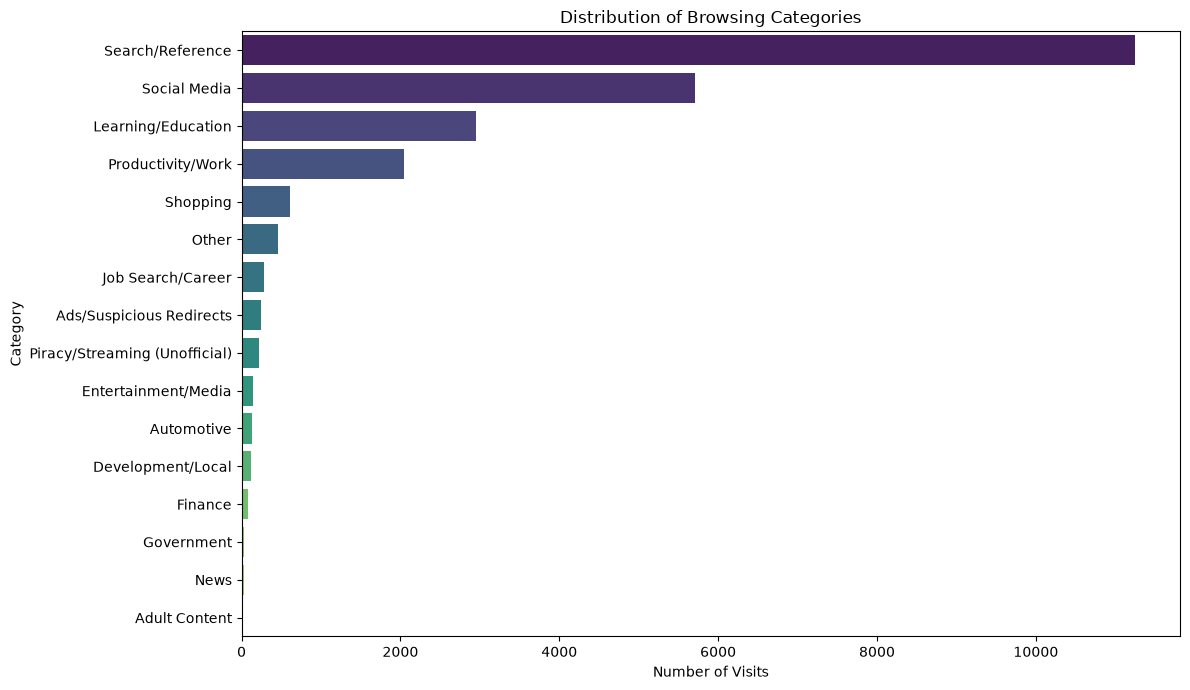

In [11]:
category_counts = chrome_data['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

plt.figure(figsize=(12, 7))
sns.barplot(x='count', y='category', data=category_counts, palette='viridis',hue = 'category')
plt.title('Distribution of Browsing Categories')
plt.xlabel('Number of Visits')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Sessionization

In [12]:
chrome_data = chrome_data.sort_values(by='timestamp').reset_index(drop=True)

inactivity_threshold_seconds = 15 * 60
chrome_data['time_diff'] = chrome_data['timestamp'].diff().dt.total_seconds()
chrome_data['new_session'] = (chrome_data['time_diff'] > inactivity_threshold_seconds) | (chrome_data['time_diff'].isna())

# Assign session IDs
chrome_data['session_id'] = chrome_data['new_session'].cumsum()

# Calculate summary statistics for each session
session_summary_df = chrome_data.groupby('session_id').agg(
    session_start=('timestamp', 'min'),
    session_end=('timestamp', 'max'),
    page_count=('url', 'count'),
    unique_domains=('domain', lambda x: x.nunique()),
    unique_categories=('category', lambda x: x.nunique()),
    primary_category=('category', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
).reset_index()

# Calculate session duration
session_summary_df['session_duration_minutes'] = (session_summary_df['session_end'] - session_summary_df['session_start']).dt.total_seconds() / 60

# Calculate domain and category switches within a session
def calculate_switches(series):
    return (series != series.shift(1)).sum() - 1
session_switches = chrome_data.groupby('session_id').agg(
    domain_switches=('domain', calculate_switches),
    category_switches=('category', calculate_switches)
).reset_index()

# Merge switches back into the session summary
session_summary_df = pd.merge(session_summary_df, session_switches, on='session_id', how='left')

# Ensure switches are not negative for sessions with 0 or 1 entry
session_summary_df['domain_switches'] = session_summary_df['domain_switches'].clip(lower=0)
session_summary_df['category_switches'] = session_summary_df['category_switches'].clip(lower=0)

# Calculate average time per page
session_summary_df['avg_time_per_page_seconds'] = (session_summary_df['session_duration_minutes'] * 60) / session_summary_df['page_count']

print(chrome_data[['timestamp', 'domain', 'session_id', 'time_diff', 'new_session']].head())
print(f"\nTotal number of sessions identified: {len(session_summary_df)}\n")
display(session_summary_df.head())

            timestamp      domain  session_id  time_diff  new_session
0 2026-05-03 10:39:00  google.com           1        NaN         True
1 2026-05-03 10:39:29  google.com           1       29.0        False
2 2026-05-03 10:40:00  google.com           1       31.0        False
3 2026-05-03 10:40:09  google.com           1        9.0        False
4 2026-05-03 10:40:19  google.com           1       10.0        False

Total number of sessions identified: 833



,session_id,session_start,session_end,page_count,unique_domains,unique_categories,primary_category,session_duration_minutes,domain_switches,category_switches,avg_time_per_page_seconds
0,1,2026-05-03 10:39:00,2026-05-03 10:40:49,8,1,1,Search/Reference,1.816667,0,0,13.625000
1,2,2026-05-03 11:24:00,2026-05-03 11:25:29,4,1,1,Search/Reference,1.483333,0,0,22.250000
2,3,2026-05-03 11:50:30,2026-05-03 11:51:29,3,2,2,Social Media,0.983333,1,1,19.666667
3,4,2026-05-03 12:27:00,2026-05-03 12:39:29,12,2,2,Search/Reference,12.483333,5,5,62.416667
4,5,2026-05-03 13:16:00,2026-05-03 13:27:49,21,1,1,Social Media,11.816667,0,0,33.761905


In [13]:
print("\nUnique values and their counts from the 'timestamp' column (top 10):")
print(chrome_data['timestamp'].value_counts().head(10))

print("\nDescriptive statistics for 'time_diff' (excluding NaNs for the first entry):")
print(chrome_data['time_diff'].dropna().describe())

print("\nNumber of events with time_diff == 0:")
print(chrome_data[chrome_data['time_diff'] == 0].shape[0])

print("\nNumber of new sessions identified (should be > 1 if timestamps are correct):")
print(chrome_data['new_session'].sum())


Unique values and their counts from the 'timestamp' column (top 10):
timestamp
2026-05-03 10:39:00    1
2026-05-03 10:39:29    1
2026-05-03 10:40:00    1
2026-05-03 10:40:09    1
2026-05-03 10:40:19    1
2026-05-03 10:40:29    1
2026-05-03 10:40:39    1
2026-05-03 10:40:49    1
2026-05-03 11:24:00    1
2026-05-03 11:24:29    1
Name: count, dtype: int64

Descriptive statistics for 'time_diff' (excluding NaNs for the first entry):
count     24320.000000
mean        319.553618
std        2978.522588
min           1.000000
25%           6.000000
50%          10.000000
75%          19.000000
max      216496.000000
Name: time_diff, dtype: float64

Number of events with time_diff == 0:
0

Number of new sessions identified (should be > 1 if timestamps are correct):
833


# Ram Correlation

In [14]:
# 1. Prepare ram_data: Convert timestamp to datetime and sort
ram_data['timestamp'] = pd.to_datetime(ram_data['timestamp'])
ram_data = ram_data.sort_values(by='timestamp').reset_index(drop=True)

# 2. Join browsing events with RAM logs using nearest timestamp merge
merged_data = pd.merge_asof(
    chrome_data,
    ram_data,
    on='timestamp',
    direction='backward', # Use the RAM log entry at or before the browsing event
    suffixes=('_chrome', '_ram')
)

print("\nMerged data (chrome_data + ram_data, first 5 rows):\n")
display(merged_data[['timestamp', 'domain', 'session_id', 'category', 'used_mb', 'usage_percent']].head())

# 3. Produce RAM stats per session
session_ram_stats = merged_data.groupby('session_id').agg(
    mean_used_mb=('used_mb', 'mean'),
    peak_used_mb=('used_mb', 'max'),
    mean_usage_percent=('usage_percent', 'mean'),
    peak_usage_percent=('usage_percent', 'max')
).reset_index()

print("\nRAM Stats per Session (first 5 rows):\n")
display(session_ram_stats.head())

# 4. Produce RAM stats per category
category_ram_stats = merged_data.groupby('category').agg(
    mean_used_mb=('used_mb', 'mean'),
    peak_used_mb=('used_mb', 'max'),
    mean_usage_percent=('usage_percent', 'mean'),
    peak_usage_percent=('usage_percent', 'max')
).reset_index()

print("\nRAM Stats per Category (all categories):\n")
display(category_ram_stats)



Merged data (chrome_data + ram_data, first 5 rows):



,timestamp,domain,session_id,category,used_mb,usage_percent
0,2026-05-03 10:39:00,google.com,1,Search/Reference,6636.9,81.02
1,2026-05-03 10:39:29,google.com,1,Search/Reference,6271.7,76.56
2,2026-05-03 10:40:00,google.com,1,Search/Reference,6221.4,75.94
3,2026-05-03 10:40:09,google.com,1,Search/Reference,6659.9,81.30
4,2026-05-03 10:40:19,google.com,1,Search/Reference,5800.3,70.80



RAM Stats per Session (first 5 rows):



,session_id,mean_used_mb,peak_used_mb,mean_usage_percent,peak_usage_percent
0,1,6250.812500,6659.9,76.302500,81.30
1,2,5484.050000,5700.9,66.945000,69.59
2,3,5367.733333,5458.4,65.523333,66.63
3,4,5954.300000,6594.3,72.684167,80.50
4,5,5823.004762,6296.0,71.080952,76.86



RAM Stats per Category (all categories):



,category,mean_used_mb,peak_used_mb,mean_usage_percent,peak_usage_percent
0,Ads/Suspicious Redirects,3448.340000,5307.6,42.096458,64.79
1,Adult Content,3434.700000,3434.7,41.930000,41.93
2,Automotive,3431.637008,3794.9,41.892362,46.32
3,Development/Local,3434.700000,3434.7,41.930000,41.93
4,Entertainment/Media,3564.582993,6075.3,43.515306,74.16
5,Finance,3434.700000,3434.7,41.930000,41.93
6,Government,3529.678378,4852.7,43.089189,59.24
7,Job Search/Career,3448.367025,5368.7,42.096810,65.54
8,Learning/Education,3435.593247,5708.7,41.940903,69.69
9,News,3625.471429,6008.6,44.258286,73.35


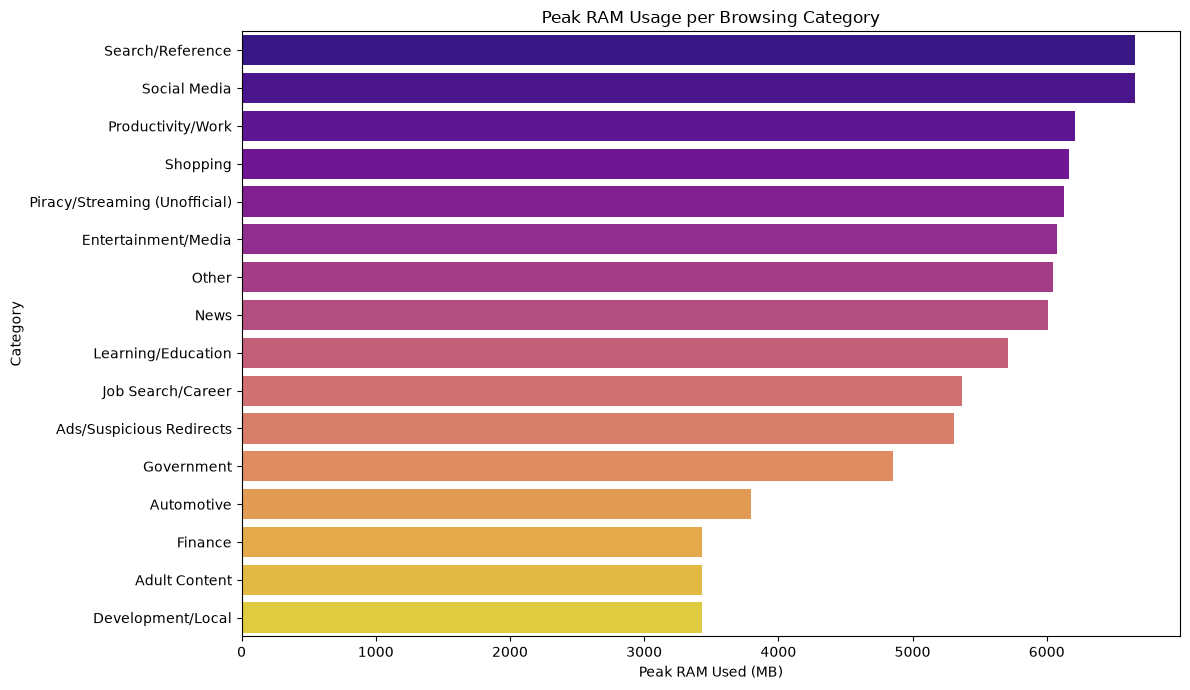

In [15]:
# Sort categories by peak RAM usage for better visualization
category_ram_stats_sorted = category_ram_stats.sort_values(by='peak_used_mb', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='peak_used_mb', y='category', data=category_ram_stats_sorted, palette='plasma',hue='category')
plt.title('Peak RAM Usage per Browsing Category')
plt.xlabel('Peak RAM Used (MB)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Clustering

For k = 2, Silhouette Score is: 0.6236
For k = 3, Silhouette Score is: 0.5828
For k = 4, Silhouette Score is: 0.3074
For k = 5, Silhouette Score is: 0.3675
For k = 6, Silhouette Score is: 0.2363
For k = 7, Silhouette Score is: 0.2379
For k = 8, Silhouette Score is: 0.2315


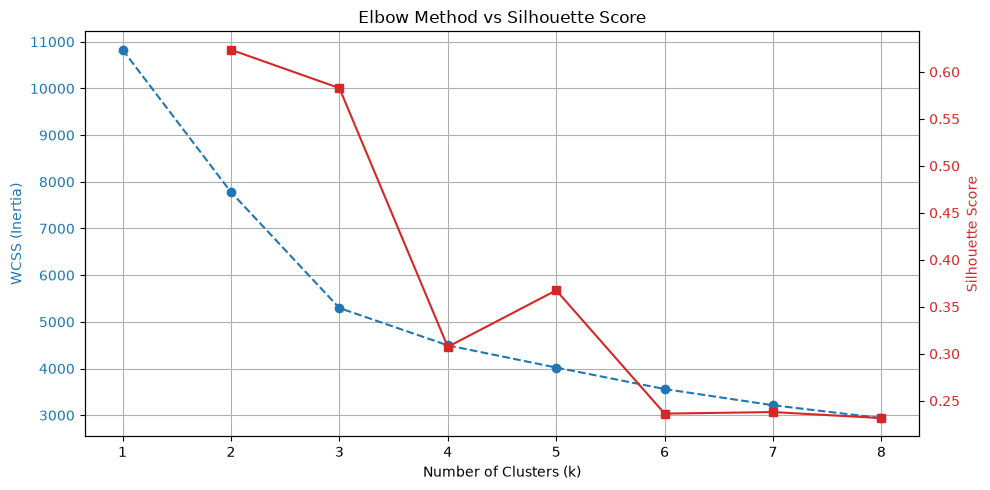

In [17]:
# 1. Combine session_summary_df and session_ram_stats
session_features = pd.merge(session_summary_df, session_ram_stats, on='session_id', how='left')

# 2. Engineer additional features (e.g., hour of day for session start)
session_features['session_start_hour'] = session_features['session_start'].dt.hour
session_features['session_start_dayofweek'] = session_features['session_start'].dt.dayofweek

# 3. Select features for clustering
features_for_clustering = [
    'session_duration_minutes', 'page_count', 'unique_domains',
    'unique_categories', 'domain_switches', 'category_switches',
    'avg_time_per_page_seconds', 'mean_used_mb', 'peak_used_mb',
    'mean_usage_percent', 'peak_usage_percent', 'session_start_hour',
    'session_start_dayofweek'
]

X = session_features[features_for_clustering].copy()

# Handle potential NaN values resulting from merging or calculations (e.g., for very short sessions)
X = X.fillna(0)

# 4. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Determine optimal number of clusters using Elbow and Silhouette Methods
wcss = []
silhouette_scores = []
k_range = range(2, min(len(X_scaled), 9)) # Silhouette score requires at least 2 clusters

# Calculate WCSS for k=1 first (since silhouette score cannot be calculated for k=1)
kmeans_1 = KMeans(n_clusters=1, init='k-means++', random_state=42, n_init=10)
kmeans_1.fit(X_scaled)
wcss.append(kmeans_1.inertia_)

for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # 1. Save Elbow metric
    wcss.append(kmeans.inertia_)

    # 2. Save Silhouette metric
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"For k = {i}, Silhouette Score is: {score:.4f}")

# Plotting both metrics side-by-side for comparison
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Elbow Method (WCSS)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(range(1, min(len(X_scaled), 9)), wcss, marker='o', linestyle='--', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Elbow Method vs Silhouette Score')
ax1.grid(True)

# Plot Silhouette Score
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()



In [ ]:
k_optimal=2

# 6. Apply KMeans clustering with the chosen k
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
session_features['cluster'] = kmeans.fit_predict(X_scaled)

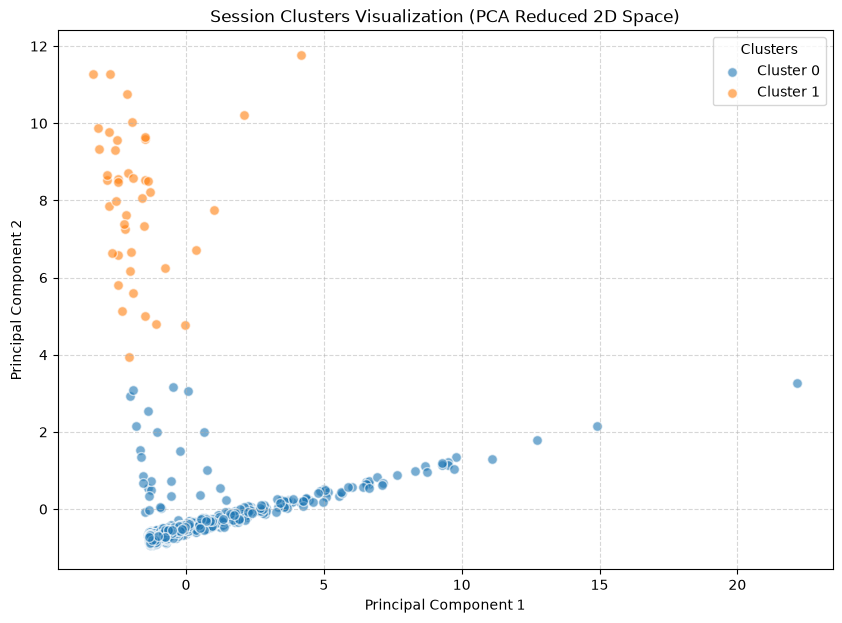

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
plot_df['Cluster'] = session_features['cluster'].values

plt.figure(figsize=(10, 7))
for cluster in range(k_optimal):
    cluster_data = plot_df[plot_df['Cluster'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}', alpha=0.6, edgecolors='w', s=50)

plt.title('Session Clusters Visualization (PCA Reduced 2D Space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Clusters')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Deep Learning

In [35]:
unique_categories = chrome_data['category'].unique()

category_to_id = {category: i for i, category in enumerate(unique_categories)}
id_to_category = {i: category for category, i in category_to_id.items()}

# Map categories in chrome_data to numerical IDs
chrome_data['category_id'] = chrome_data['category'].map(category_to_id)

# Create sequences of category IDs for each session.
session_sequences = chrome_data.groupby('session_id')['category_id'].apply(list).tolist()

# Prepare input-output pairs (X, y) with a fixed sequence length.
fixed_sequence_length = 5

X_sequences = []
y_next_category = []

for seq in session_sequences:
    if len(seq) > fixed_sequence_length:
        for i in range(len(seq) - fixed_sequence_length):
            X_sequences.append(seq[i:i+fixed_sequence_length]) # Fixed-length input sequence
            y_next_category.append(seq[i+fixed_sequence_length]) # The next category to predict

# For fixed-length sequences, np.array directly creates the correct shape (no need for custom padding function)
X_padded = np.array(X_sequences)

# Convert to PyTorch tensors
X_tensor = torch.LongTensor(X_padded)
y_tensor = torch.LongTensor(y_next_category)

# Update max_sequence_length to the new fixed length for clarity and consistency with model input
max_sequence_length = fixed_sequence_length

print(f"Number of sequences for training: {len(X_sequences)}")
print(f"Fixed sequence length: {max_sequence_length}")
print(f"Number of unique categories: {len(unique_categories)}")
print(f"Sample X_tensor shape: {X_tensor.shape}")
print(f"Sample y_tensor shape: {y_tensor.shape}")

Number of sequences for training: 20683
Fixed sequence length: 5
Number of unique categories: 16
Sample X_tensor shape: torch.Size([20683, 5])
Sample y_tensor shape: torch.Size([20683])


In [36]:
# Split data into training and testing sets
try:
    X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor)
except ValueError:
    print("Warning: Stratification not possible due to insufficient samples in some classes. Splitting without stratification.")
    X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [37]:
# Create a custom Dataset
class CategorySequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CategorySequenceDataset(X_train, y_train)
test_dataset = CategorySequenceDataset(X_test, y_test)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [44]:
class CategoryPredictor(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, output_dim, dropout_prob=0.5):
        super(CategoryPredictor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout_prob)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        last_hidden_state = hidden[-1, :, :]
        out = self.dropout(last_hidden_state)
        out = self.fc(out)
        return out

In [43]:
# Model parameters
vocab_size = len(unique_categories) # Number of unique categories
embed_dim = 128                     # Dimension of category embeddings
hidden_dim = 256                    # Number of features in the LSTM hidden state
num_layers = 2                      # Number of recurrent layers
output_dim = vocab_size             # Number of output classes (next category prediction)

# Instantiate the model
model = CategoryPredictor(vocab_size, embed_dim, hidden_dim, num_layers, output_dim)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print("LSTM model defined and moved to device:", device)
print("\n",model)

LSTM model defined and moved to device: cpu

 CategoryPredictor(
  (embedding): Embedding(16, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=256, out_features=16, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)



Starting model training...
Epoch 1/10, Train Loss: 0.7191, Test Accuracy: 0.8528
Epoch 2/10, Train Loss: 0.5909, Test Accuracy: 0.8521
Epoch 3/10, Train Loss: 0.5771, Test Accuracy: 0.8545
Epoch 4/10, Train Loss: 0.5674, Test Accuracy: 0.8513
Epoch 5/10, Train Loss: 0.5615, Test Accuracy: 0.8550
Epoch 6/10, Train Loss: 0.5586, Test Accuracy: 0.8562
Epoch 7/10, Train Loss: 0.5533, Test Accuracy: 0.8552
Epoch 8/10, Train Loss: 0.5456, Test Accuracy: 0.8542
Epoch 9/10, Train Loss: 0.5417, Test Accuracy: 0.8562
Epoch 10/10, Train Loss: 0.5438, Test Accuracy: 0.8571

Training complete.

Detailed Classification Report on Test Set:
                               precision    recall  f1-score   support

             Search/Reference       0.87      0.89      0.88      1813
                 Social Media       0.94      0.92      0.93      1028
                         News       0.33      0.25      0.29         4
            Job Search/Career       0.73      0.72      0.73        50
          

/home/abishek/projects/guvi-final/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/abishek/projects/guvi-final/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/abishek/projects/guvi-final/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

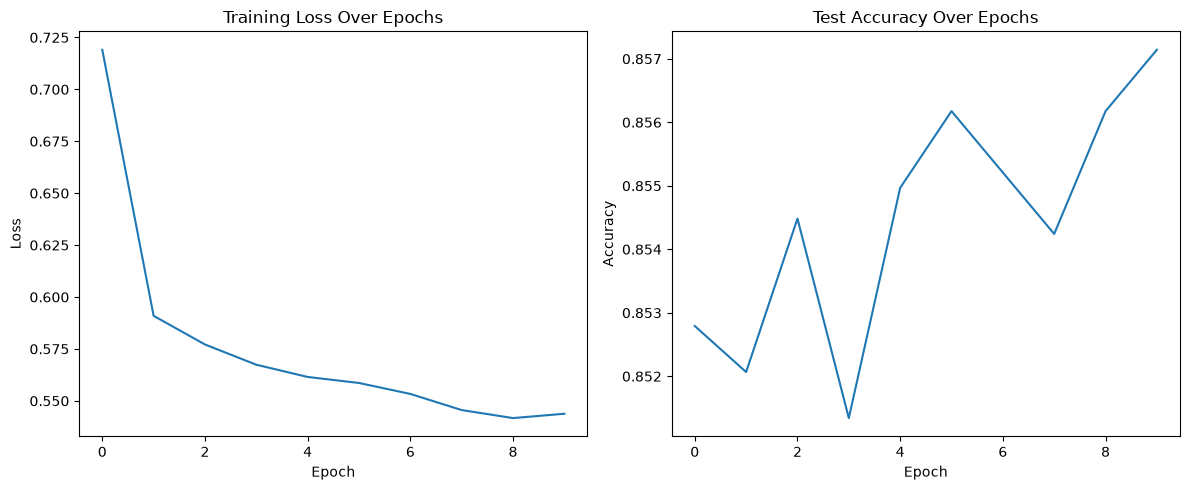

In [45]:
# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10

train_losses = []
test_accuracies = []

print("\nStarting model training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Compute loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Evaluate on the test set
    model.eval() # Set model to evaluation mode
    correct_predictions = 0
    total_predictions = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad(): # Disable gradient calculation during evaluation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    test_accuracy = correct_predictions / total_predictions
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

print("\nTraining complete.")

# Evaluation
print("\nDetailed Classification Report on Test Set:")
print(classification_report(all_labels, all_predictions, target_names=unique_categories))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(test_accuracies)
plt.title('Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()